In [1]:
%load_ext autoreload
%autoreload 2

from functools import partial
from pathlib import Path
from typing import Optional

from flax import nnx
from jaxtyping import Array
import tensorflow_datasets as tfds
import numpy as np
from tqdm.auto import tqdm

import jax
import jax.numpy as jnp
import optax

import matplotlib.pyplot as plt

from trainax._dataloader import JaxLoader
from trainax._trainer import NNXTrainer
from trainax._types import StepOutput, ValStepOutput
from trainax._callbacks import (
    EpochLogger,
    LossMetricTracker,
    NNXMetricTracker,
    PbarHandler
)

%matplotlib inline

In [2]:
class CNN(nnx.Module):
  """A simple CNN model."""

  def __init__(self, *, rngs: nnx.Rngs):
    self.rngs = rngs
    self.conv1 = nnx.Conv(1, 32, kernel_size=(3, 3), rngs=rngs)
    self.batch_norm1 = nnx.BatchNorm(32, rngs=rngs)
    self.dropout1 = nnx.Dropout(rate=0.025, rngs=rngs)
    self.conv2 = nnx.Conv(32, 64, kernel_size=(3, 3), rngs=rngs)
    self.batch_norm2 = nnx.BatchNorm(64, rngs=rngs)
    self.avg_pool = partial(nnx.avg_pool, window_shape=(2, 2), strides=(2, 2))
    self.linear1 = nnx.Linear(3136, 256, rngs=rngs)
    self.dropout2 = nnx.Dropout(rate=0.025, rngs=rngs)
    self.linear2 = nnx.Linear(256, 10, rngs=rngs)

  def __call__(self, x):
    x = self.avg_pool(nnx.relu(self.batch_norm1(self.dropout1(self.conv1(x), rngs=self.rngs))))
    x = self.avg_pool(nnx.relu(self.batch_norm2(self.conv2(x))))
    x = x.reshape(x.shape[0], -1)  # flatten
    x = nnx.relu(self.dropout2(self.linear1(x), rngs=self.rngs))
    x = self.linear2(x)
    return x

# Instantiate the model.
model = CNN(rngs=nnx.Rngs(0))
# Visualize it.
nnx.display(model)

In [3]:
def loss_fn(model: CNN, data: dict[str, Array]):
    logits = model(data["x"])
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=data["label"]
    ).mean()
    return loss, logits


def train_step(model: CNN, batch: dict[str, Array]):
    (loss, logits), grads = nnx.value_and_grad(loss_fn, has_aux=True)(
        model, batch
    )
    return StepOutput(
        loss=loss,
        y=batch["label"],
        yhat=jax.nn.softmax(logits),
        gradients=grads,
    )


def eval_step(model: CNN, batch: dict[str, Array], metrics: nnx.metrics.Metric | None = None):
    loss, logits = loss_fn(model, batch)

    preds = jax.nn.softmax(logits)
    acc = jnp.mean(jnp.argmax(preds, axis=1) == batch["x"])

    if metrics is not None:
        metrics.update(loss=loss, logits=logits, labels=batch["label"])
    
    return ValStepOutput(
        loss,
        batch["label"],
        preds,
        metrics={"acc": acc}
    )

In [4]:
def get_datasets(
    batch_size: int = 2000,
    seed: int = 42,
    val_size: float = 0.2,
    **kwargs
) -> tuple[JaxLoader, JaxLoader, JaxLoader]:
    """Load MNIST train and test datasets into memory."""
    ds_builder = tfds.builder("mnist")
    ds_builder.download_and_prepare()
    
    train_ds = tfds.as_numpy(ds_builder.as_dataset(split="train", batch_size=-1))
    test_ds = tfds.as_numpy(ds_builder.as_dataset(split="test", batch_size=-1))
    
    train_ds["x"] = jnp.float32(train_ds.pop("image")) / 255.0
    test_ds["x"] = jnp.float32(test_ds.pop("image")) / 255.0

    idxs = np.arange(train_ds["x"].shape[0])
    np.random.default_rng(42).shuffle(idxs)

    n_val = int(val_size * idxs.size)
    
    return (
        JaxLoader({k: v[n_val:, ...] for k, v in train_ds.items()}, batch_size, **kwargs),
        JaxLoader({k: v[:n_val, ...] for k, v in train_ds.items()}, batch_size, **kwargs),
        JaxLoader(test_ds, min(batch_size, test_ds["x"].shape[0]), **kwargs)
    )

In [5]:
train_mnist, val_mnist, test_mnist = get_datasets()
train_mnist, val_mnist, test_mnist

(JaxLoader(Data attributes: ['label', 'x'] | N samples: 48000 | Batch size: 2000 | N batches: 24 | Sharding: None),
 JaxLoader(Data attributes: ['label', 'x'] | N samples: 12000 | Batch size: 2000 | N batches: 6 | Sharding: None),
 JaxLoader(Data attributes: ['label', 'x'] | N samples: 10000 | Batch size: 2000 | N batches: 5 | Sharding: None))

In [6]:
jax.config.update("jax_disable_jit", False)

log_path = Path("/Users/nikolai/misc/jax-trainer/notebooks/example_logs")

learning_rate = 0.005
momentum = 0.9

model = CNN(rngs=nnx.Rngs(42))
optimizer = optax.adamw(learning_rate, momentum)
metrics = nnx.MultiMetric(
  accuracy=nnx.metrics.Accuracy(),
  loss=nnx.metrics.Average('loss'),
)

trainer = NNXTrainer(
    n_epochs=6,
    callbacks=[
        EpochLogger(),
        LossMetricTracker(),
        NNXMetricTracker(metrics),
        PbarHandler(),
    ],
    continuous_files={
        "train_loss": log_path / "train_loss.csv",
        "val_loss": log_path / "val_loss.csv",
    },
    val_every=2,
    use_rich=False,
)

trained_model, _ = trainer.train(
    model=model,
    optim=optimizer,
    train_step=train_step,
    trainloader=train_mnist,
    val_step=eval_step,
    valloader=val_mnist,
)
# to not accidentally record batch stats later on
trained_model.eval()

Training epochs [0/6 |   0%]            [00:00<?, ?it/s] 

Epoch steps [0/24 |   0%]            [00:00<?, ?it/s]

Validation steps [0/6 |   0%]            [00:00<?, ?it/s]

Validation steps [0/6 |   0%]            [00:00<?, ?it/s]

Validation steps [0/6 |   0%]            [00:00<?, ?it/s]

In [13]:
trained_model.eval()
test_output = []
for batch_data in tqdm(test_mnist, desc="Test Steps"):
    test_output.append(
        eval_step(
            trained_model,
            batch_data,
            trainer.callbacks["NNXMetricTracker"].metrics
        )
    )
test_metrics = trainer.callbacks["NNXMetricTracker"].metrics.compute()

Test Steps:   0%|          | 0/5 [00:00<?, ?it/s]

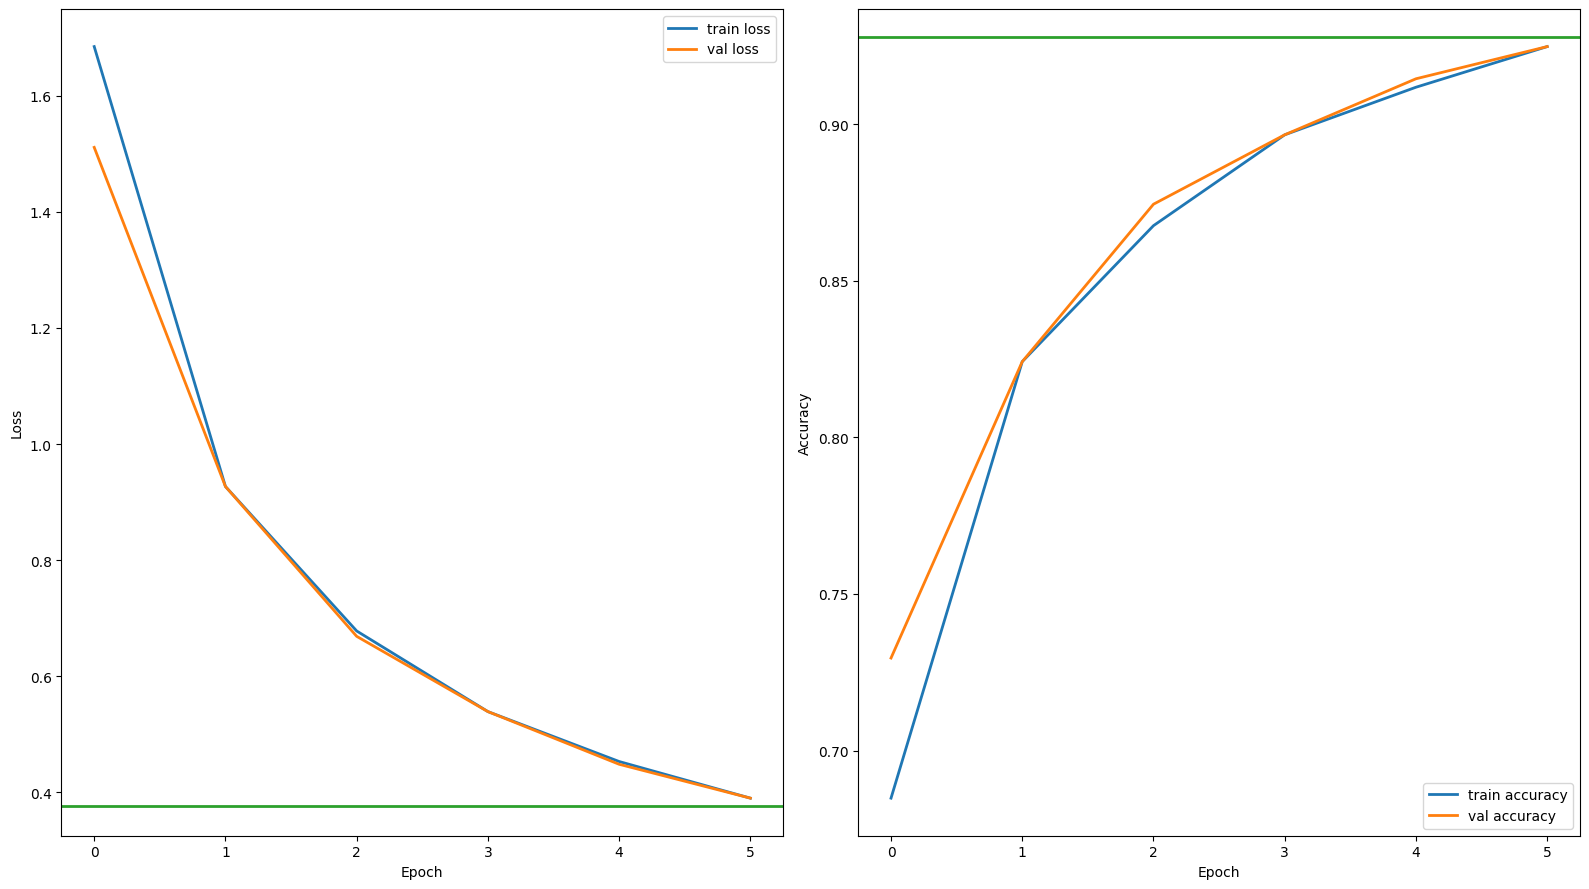

In [15]:
fig, axes = plt.subplots(ncols=2, figsize=(16, 9))

trainer.callbacks["NNXMetricTracker"].plot_metric("loss", ax=axes[0], linewidth=2)
axes[0].axhline(y=test_metrics["loss"], label="test Loss", c="tab:green", linewidth=2)
trainer.callbacks["NNXMetricTracker"].plot_metric("accuracy", ax=axes[1], linewidth=2)
axes[1].axhline(y=test_metrics["accuracy"], label="test Accuracy", c="tab:green", linewidth=2)

plt.tight_layout()
plt.show()